<a href="https://colab.research.google.com/github/molluIdontknow/ELE_Algorithm/blob/%EB%B0%95%EC%84%9C%ED%98%84/ELEalgo_MLP%EC%9D%98_%EC%82%AC%EB%B3%B8.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Dataset Load
실험 Dataset: California housing

In [8]:
import pandas as pd
from sklearn.datasets import fetch_california_housing

# 캘리포니아 하우싱 데이터셋 로드
housing = fetch_california_housing(as_frame=True)
df = housing.frame
CSV_FILEPATH = "california_housing.csv"
df.to_csv(CSV_FILEPATH, index=False)

# Config

* 라이브러리 불러오기
* hyperparameter 조정

In [9]:
import os
import random
import numpy as np
import pandas as pd

import torch
import torch.nn as nn
import torch.optim as optim

from torch.utils.data import Dataset, DataLoader

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

from sklearn.metrics import (
    mean_squared_error,
    mean_absolute_error,
    r2_score)


# hyperparamter 조정
CONFIG = {
    "batch_size": 100,
    "epochs": 20,
    "learning_rate": 0.001,
    "weight_decay": 0.0001,
    "patience": 20,
    "random_seed": 42
}


def set_seed(seed):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)


set_seed(CONFIG["random_seed"])

# 기본 실행 코드
MLP 구조: N -> 16 -> 8 ->1

In [10]:
# 데이터셋 클래스 (CSV 파일 읽기)
class BatteryCSVDataset(Dataset):
    def __init__(self, x, y):
        self.x = torch.tensor(x, dtype=torch.float32)
        self.y = torch.tensor(y, dtype=torch.float32).unsqueeze(1)

    def __len__(self):
        return len(self.x)

    def __getitem__(self, idx):
        return self.x[idx], self.y[idx]


# MLP 모델 클래스
class SOHPredictorMLP(nn.Module):
    def __init__(self, input_dim):
        super().__init__()

        self.network = nn.Sequential(
            nn.Linear(input_dim, 16),
            nn.ReLU(),
            nn.Linear(16, 8),
            nn.ReLU(),
            nn.Linear(8, 1)
        )

    def forward(self, x):
        return self.network(x)

# Dataset Loader
*   Feature, Target 설정
*   Dataset Split: Train 8 / Val 1 / Test 1




In [11]:
CSV_FILENAME = "california_housing.csv"

# Feature, Target 설정
FEATURES = ["MedInc", "HouseAge", "AveRooms", "Population", "AveOccup", "Latitude", "Longitude"]
TARGET = "MedHouseVal"

df = pd.read_csv(CSV_FILENAME)

X = df[FEATURES].values
y = df[TARGET].values

# Dataset Split
X_train, X_temp, y_train, y_temp = train_test_split(
    X, y,
    test_size=0.2,
    random_state=CONFIG["random_seed"])

X_val, X_test, y_val, y_test = train_test_split(
    X_temp, y_temp,
    test_size=0.5,
    random_state=CONFIG["random_seed"])

scaler = StandardScaler()

X_train = scaler.fit_transform(X_train)
X_val = scaler.transform(X_val)
X_test = scaler.transform(X_test)

train_dataset = BatteryCSVDataset(X_train, y_train)
val_dataset = BatteryCSVDataset(X_val, y_val)
test_dataset = BatteryCSVDataset(X_test, y_test)

# DataLoader
train_loader = DataLoader(
    train_dataset,
    batch_size=CONFIG["batch_size"],
    shuffle=True)

val_loader = DataLoader(
    val_dataset,
    batch_size=CONFIG["batch_size"],
    shuffle=False)

test_loader = DataLoader(
    test_dataset,
    batch_size=CONFIG["batch_size"],
    shuffle=False)

# Train/Val/Test 별 Data 개수 출력
print("Train:", len(train_dataset))
print("Validation:", len(val_dataset))
print("Test:", len(test_dataset))

Train: 16512
Validation: 2064
Test: 2064


# Epoch 실행

*   Loss: MSE
*   Optimizer: Adam
*   Weight decay 적용: overfitting 방지
*   Learning rate Scheduler: 기준 5번
*   Early Stopping: 기준 Config에서 설정





In [12]:
model = SOHPredictorMLP(input_dim=len(FEATURES))

criterion = nn.MSELoss()

optimizer = optim.Adam(
    model.parameters(),
    lr=CONFIG["learning_rate"],
    weight_decay=CONFIG["weight_decay"])

# Learning rate Schedler
scheduler = optim.lr_scheduler.ReduceLROnPlateau(
    optimizer,
    mode="min",
    factor=0.5,
    patience=5
)

best_val_loss = float("inf")
patience_count = 0

train_losses = []
val_losses = []

# Epoch 실행
for epoch in range(1, CONFIG["epochs"] + 1):

    model.train()
    train_loss = 0

    for batch_x, batch_y in train_loader:
        optimizer.zero_grad()
        pred_y = model(batch_x)
        loss = criterion(pred_y, batch_y)
        loss.backward()
        optimizer.step()
        train_loss += loss.item()

    train_loss /= len(train_loader)

    model.eval()
    val_loss = 0

    with torch.no_grad():

        for batch_x, batch_y in val_loader:
            pred_y = model(batch_x)
            loss = criterion(pred_y, batch_y)
            val_loss += loss.item()

    val_loss /= len(val_loader)

    scheduler.step(val_loss)

    train_losses.append(train_loss)
    val_losses.append(val_loss)

    print(
        f"Epoch [{epoch}/{CONFIG['epochs']}] "
        f"Train Loss: {train_loss:.4f} "
        f"Val Loss: {val_loss:.4f}"
    )


    # best validation 값 저장
    if val_loss < best_val_loss:
        best_val_loss = val_loss

        patience_count = 0

        torch.save(
            model.state_dict(),
            "best_mlp_model.pth")
    else:
        patience_count += 1

    # Early Stopping -> 기준 config에서 설정
    if patience_count >= CONFIG["patience"]:
        print("Early stopping")
        break

Epoch [1/20] Train Loss: 2.8510 Val Loss: 1.0988
Epoch [2/20] Train Loss: 0.8701 Val Loss: 0.6758
Epoch [3/20] Train Loss: 0.6222 Val Loss: 0.5745
Epoch [4/20] Train Loss: 0.5351 Val Loss: 0.5214
Epoch [5/20] Train Loss: 0.4898 Val Loss: 0.4875
Epoch [6/20] Train Loss: 0.4621 Val Loss: 0.4669
Epoch [7/20] Train Loss: 0.4446 Val Loss: 0.4486
Epoch [8/20] Train Loss: 0.4287 Val Loss: 0.4342
Epoch [9/20] Train Loss: 0.4207 Val Loss: 0.4264
Epoch [10/20] Train Loss: 0.4090 Val Loss: 0.4194
Epoch [11/20] Train Loss: 0.4023 Val Loss: 0.4117
Epoch [12/20] Train Loss: 0.3955 Val Loss: 0.4044
Epoch [13/20] Train Loss: 0.3904 Val Loss: 0.4039
Epoch [14/20] Train Loss: 0.3850 Val Loss: 0.3972
Epoch [15/20] Train Loss: 0.3796 Val Loss: 0.3942
Epoch [16/20] Train Loss: 0.3780 Val Loss: 0.3943
Epoch [17/20] Train Loss: 0.3729 Val Loss: 0.3935
Epoch [18/20] Train Loss: 0.3708 Val Loss: 0.3824
Epoch [19/20] Train Loss: 0.3667 Val Loss: 0.3814
Epoch [20/20] Train Loss: 0.3629 Val Loss: 0.3772


# Loss Curve




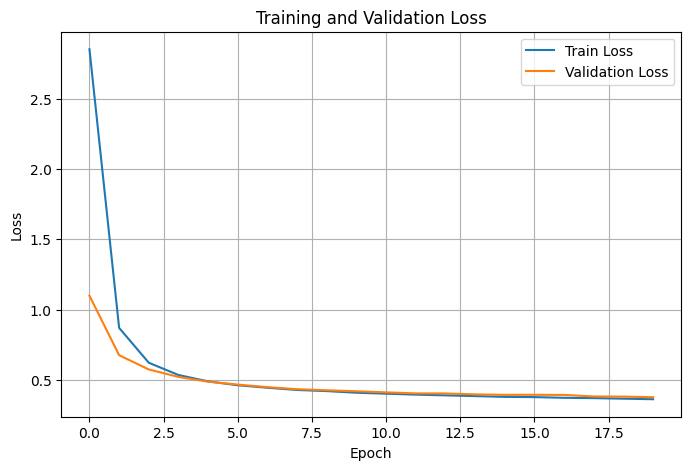

In [13]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 5))

plt.plot(
    train_losses,
    label="Train Loss")

plt.plot(
    val_losses,
    label="Validation Loss")

plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Training and Validation Loss")

plt.legend()
plt.grid()
plt.show()

# Result

In [14]:
model.load_state_dict(torch.load("best_mlp_model.pth"))
model.eval()

predictions = []
actuals = []

with torch.no_grad():
    for batch_x, batch_y in test_loader:
        pred_y = model(batch_x)

        predictions.extend(pred_y.numpy().flatten())
        actuals.extend(batch_y.numpy().flatten())

predictions = np.array(predictions)
actuals = np.array(actuals)

# Test Loss
test_loss = mean_squared_error(actuals, predictions)

print("Test Loss:", round(test_loss, 4))

# 무작위 10개 결과 확인
random_indices = np.random.choice(
    len(actuals),
    size=10,
    replace=False
)

sample_actuals = actuals[random_indices]
sample_predictions = predictions[random_indices]

abs_error = np.abs(sample_actuals - sample_predictions)
error_rate_pct = (abs_error / np.maximum(np.abs(sample_actuals), 1e-8)) * 100

result_df = pd.DataFrame({
    "Actual": np.round(sample_actuals, 4),
    "Prediction": np.round(sample_predictions, 4),
    "Absolute Error": np.round(abs_error, 4),
    "Error Rate (%)": np.round(error_rate_pct, 2)})

print("\nPrediction Result")
print(result_df.to_string(index=False))

Test Loss: 0.3675

Prediction Result
 Actual  Prediction  Absolute Error  Error Rate (%)
  1.185      1.2945          0.1095        9.240000
  1.563      0.6601          0.9029       57.770000
  1.199      1.3743          0.1753       14.620000
  4.500      1.9002          2.5998       57.770000
  2.832      3.6834          0.8514       30.059999
  1.000      0.8951          0.1049       10.490000
  3.302      3.1851          0.1169        3.540000
  1.935      1.8338          0.1012        5.230000
  2.531      3.2066          0.6756       26.690001
  2.722      2.5617          0.1603        5.890000
